In [1]:
import os, random, numpy as np, tensorflow as tf

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


2025-12-21 01:14:06.975970: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-21 01:14:07.024779: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-21 01:14:08.369537: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# BiLSTM-based Intrusion Detection on TON IoT Dataset (Rewritten)

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from collections import Counter
from sklearn.model_selection import StratifiedKFold, train_test_split

# Load Dataset
df = pd.read_csv('../dataset/final_df.csv', low_memory=False)
print("Original DataFrame Head:\n", df.head())
print("\nOriginal Class Distribution:\n", df['type'].value_counts())
print("\nOriginal Label Distribution:\n", df['label'].value_counts())
print("\nOriginal Data Types:\n", df.dtypes)
print("\nOriginal Data Shapes:\n", df.shape)

# --- Data Preprocessing ---
# Clean and impute
df['src_bytes'] = pd.to_numeric(df['src_bytes'], errors='coerce').fillna(0)
df.drop_duplicates(inplace=True)

df.fillna(df.mean(numeric_only=True), inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col].fillna('Missing', inplace=True) # Or df[col].mode()[0]
        else:
            df[col].fillna(df[col].mean(), inplace=True)

print(f"Shape after handling NaNs: {df.shape}")

# Identify targets
TARGET_LABEL = 'label'
TARGET_TYPE = 'type'

# Encode categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if TARGET_TYPE in categorical_cols:
    categorical_cols.remove(TARGET_TYPE)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Encoded column: {col}")

# Normalize numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if TARGET_LABEL in numerical_cols:
    numerical_cols.remove(TARGET_LABEL)

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

binary_y = df[TARGET_LABEL].values
type_encoder = LabelEncoder()
y_multiclass_encoded = type_encoder.fit_transform(df[TARGET_TYPE])
num_classes = len(le.classes_)
# Convert to one-hot encoding for Keras if using categorical_crossentropy
y_multiclass_onehot = to_categorical(y_multiclass_encoded)

y_multiclass_labels = np.argmax(y_multiclass_onehot, axis=1)

# Drop targets from features
X = df.drop(columns=[TARGET_LABEL, TARGET_TYPE]).values
print("Feature shape (flat):", X.shape)
print("Binary target shape:", binary_y.shape)
print("Multi-class target shape:", y_multiclass_labels.shape)

# print the class distribution of binary_y and y_multiclass_labels
print("Binary target class distribution:")
print(Counter(binary_y))
print("Multi-class target class distribution:")
print(Counter(y_multiclass_labels))

Original DataFrame Head:
            ts         src_ip  src_port        dst_ip  dst_port proto service  \
0  1556499101  192.168.1.193     60396  192.168.1.33      8080   tcp       -   
1  1556494424  192.168.1.193     59273  192.168.1.33      8080   tcp       -   
2  1556487945  192.168.1.193     57717  192.168.1.33      8080   tcp       -   
3  1556508616  192.168.1.193     62682  192.168.1.33        80   tcp       -   
4  1556511697  192.168.1.193     63419  192.168.1.33      8080   tcp       -   

   duration src_bytes  dst_bytes  ... http_response_body_len  \
0  0.000180         0          0  ...                      0   
1  0.000111         0          0  ...                      0   
2  0.000148         0          0  ...                      0   
3  0.000127         0          0  ...                      0   
4  0.000122         0          0  ...                      0   

   http_status_code  http_user_agent  http_orig_mime_types  \
0                 0                -          

In [3]:
# 1. Split BEFORE SMOTE (to avoid leakage)
# ----------------------------------------
X_train, X_test, y_train_multi, y_test_multi = train_test_split(
    X,
    y_multiclass_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_multiclass_encoded  # stratify on binary for this example
)

# Reset indices
X_train = pd.DataFrame(X_train).reset_index(drop=True).values
X_test = pd.DataFrame(X_test).reset_index(drop=True).values

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train_multiclass labels shape: {y_train_multi.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_test_multiclass labels shape: {y_test_multi.shape}")

# print the class distribution of binary_y and y_multiclass
# print the class distribution of binary_y and y_multiclass
print("Multi-class target class distribution (train):")
print(Counter(np.argmax(y_train_multi, axis=1)))
print("Multi-class target class distribution (test):")
print(Counter(np.argmax(y_test_multi, axis=1)))

# scaling the training data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling complete.")


X_train shape: (352834, 44)
y_train_multiclass labels shape: (352834, 9)
X_test  shape: (88209, 44)
y_test_multiclass labels shape: (88209, 9)
Multi-class target class distribution (train):
Counter({np.int64(5): 240000, np.int64(0): 16000, np.int64(6): 16000, np.int64(7): 16000, np.int64(8): 16000, np.int64(2): 16000, np.int64(1): 16000, np.int64(3): 16000, np.int64(4): 834})
Multi-class target class distribution (test):
Counter({np.int64(5): 60000, np.int64(1): 4000, np.int64(3): 4000, np.int64(6): 4000, np.int64(0): 4000, np.int64(8): 4000, np.int64(7): 4000, np.int64(2): 4000, np.int64(4): 209})
Scaling complete.


In [ ]:
# --- Create Sequences ---
def create_sequences(
    X,
    y,
    window_size: int = 10,
    debug: bool = False,
    trace_limit: int = 5
):
    # Convert to numpy if not already
    X = np.asarray(X)
    y = np.asarray(y)

    # Input validation
    if len(X) != len(y):
        raise ValueError("X and y must have the same number of samples")
    if len(X.shape) != 2:
        raise ValueError("X must be a 2D array: (samples, features)")
    if len(y.shape) > 2:
        raise ValueError("y must be a 1D or 2D array")

    X_seq, y_seq = [], []
    total = len(X) - window_size + 1
    if debug:
        print(f"Total samples: {len(X)} | Generating {total} sequences (window_size={window_size})")

    for i in range(total):
        window = X[i : i + window_size]
        label = y[i + window_size - 1]
        X_seq.append(window)
        y_seq.append(label)

        if debug and i < trace_limit:
            print(f"\n--- Seq {i+1}/{total} ---")
            print(f"  X indices: {i} to {i+window_size-1}")
            print(f"  y index:   {i+window_size-1} → label={label}")
            print(f"  window.shape: {window.shape}")

    if debug:
        print(f"\nTotal sequences generated: {len(X_seq)}")

    return np.array(X_seq), np.array(y_seq)


TIMESTEPS = 10
X_train_seq, y_train_seq = create_sequences(X_train, y_train_multi, window_size=TIMESTEPS, debug=True)
X_test_seq, y_test_seq = create_sequences(X_test, y_test_multi, window_size=TIMESTEPS, debug=True)


print("Train sequence shape:", X_train_seq.shape)  # (samples, timesteps, features)
print("Test sequence shape:", X_test_seq.shape)
print("multi target distribution:", Counter(np.argmax(y_train_multi, axis=1)))

# counters
print("Class distribution in y_train_seq:", Counter(np.argmax(y_train_seq, axis=1)))
print("Class distribution in y_test_seq:", Counter(np.argmax(y_test_seq, axis=1)))

# multiclass sequence generation.
# X_train_seq_multi, y_train_seq_multi = create_sequences(X_train, y_train_multi, debug=True)
# X_test_seq_multi, y_test_seq_multi = create_sequences(X_test, y_test_multi, debug=True)


Total samples: 352834 | Generating 352825 sequences (window_size=10)

--- Seq 1/352825 ---
  X indices: 0 to 9
  y index:   9 → label=[0. 0. 0. 0. 0. 0. 0. 1. 0.]
  window.shape: (10, 44)

--- Seq 2/352825 ---
  X indices: 1 to 10
  y index:   10 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shape: (10, 44)

--- Seq 3/352825 ---
  X indices: 2 to 11
  y index:   11 → label=[0. 0. 0. 0. 0. 0. 0. 0. 1.]
  window.shape: (10, 44)

--- Seq 4/352825 ---
  X indices: 3 to 12
  y index:   12 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shape: (10, 44)

--- Seq 5/352825 ---
  X indices: 4 to 13
  y index:   13 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shape: (10, 44)

Total sequences generated: 352825
Total samples: 88209 | Generating 88200 sequences (window_size=10)

--- Seq 1/88200 ---
  X indices: 0 to 9
  y index:   9 → label=[0. 0. 0. 0. 0. 0. 0. 0. 1.]
  window.shape: (10, 44)

--- Seq 2/88200 ---
  X indices: 1 to 10
  y index:   10 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shap

In [5]:
from imblearn.over_sampling import ADASYN
from collections import Counter

# Convert one-hot to integer labels for y_train_seq
y_train_seq_labels = np.argmax(y_train_seq, axis=1)

# Apply ADASYN instead of SMOTE
adasyn = ADASYN(
    sampling_strategy={4: 16000},  # Only oversample class 4
    random_state=42,
    n_neighbors=5
)
X_train_res, y_train_res = adasyn.fit_resample(
	X_train_seq.reshape(X_train_seq.shape[0], -1),  # Flatten for ADASYN
	y_train_seq_labels
)
X_train_res = X_train_res.reshape(X_train_res.shape[0], TIMESTEPS, X_train_seq.shape[2])  # Reshape back to sequences
y_train_res = to_categorical(y_train_res, num_classes=y_train_seq.shape[1])  # One-hot encode	
print("After ADASYN:")
print("Resampled X_train shape:", X_train_res.shape)
print("Resampled y_train shape:", y_train_res.shape)
print("Resampled class distribution:", Counter(np.argmax(y_train_res, axis=1)))

After ADASYN:
Resampled X_train shape: (367686, 10, 44)
Resampled y_train shape: (367686, 9)
Resampled class distribution: Counter({np.int64(5): 239994, np.int64(8): 16000, np.int64(2): 16000, np.int64(1): 16000, np.int64(3): 16000, np.int64(7): 15999, np.int64(6): 15999, np.int64(0): 15999, np.int64(4): 15695})


In [6]:
# split a validation set from training data
stratify_labels = np.argmax(y_train_res, axis=1)

X_train_seq_final, X_val_seq, y_train_seq_final, y_val_seq = train_test_split(
    X_train_res,
    y_train_res,
    test_size=0.2,
    random_state=42,
    stratify=stratify_labels
)
print("Final training shape:", X_train_seq_final.shape)
print("Validation shape:", X_val_seq.shape)
print("Final training labels shape:", y_train_seq_final.shape)
print("Validation labels shape:", y_val_seq.shape)

print("Final training label distributions:")
print(f"y_train_seq_final distribution: {Counter(np.argmax(y_train_seq_final, axis=1))}")
print(f"y_val_seq distribution: {Counter(np.argmax(y_val_seq, axis=1))}")

Final training shape: (294148, 10, 44)
Validation shape: (73538, 10, 44)
Final training labels shape: (294148, 9)
Validation labels shape: (73538, 9)
Final training label distributions:
y_train_seq_final distribution: Counter({np.int64(5): 191995, np.int64(3): 12800, np.int64(8): 12800, np.int64(1): 12800, np.int64(2): 12800, np.int64(0): 12799, np.int64(6): 12799, np.int64(7): 12799, np.int64(4): 12556})
y_val_seq distribution: Counter({np.int64(5): 47999, np.int64(7): 3200, np.int64(0): 3200, np.int64(6): 3200, np.int64(8): 3200, np.int64(3): 3200, np.int64(2): 3200, np.int64(1): 3200, np.int64(4): 3139})


In [ ]:
from tensorflow.keras.metrics import Metric


def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # Clip predictions to avoid log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        
        # Compute cross entropy
        ce = -y_true * tf.math.log(y_pred)
        
        # Compute focal weight
        weight = alpha * tf.pow(1 - y_pred, gamma)
        
        # Apply focal loss
        fl = weight * ce
        
        # Reduce across classes and samples
        return tf.reduce_mean(tf.reduce_sum(fl, axis=-1))
    
    return loss

In [8]:
frequencies = np.sum(y_train_seq_final, axis=0)
median_freq = np.median(frequencies)
class_weights = {cls: median_freq / count for cls, count in enumerate(frequencies)}

print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0000781311039926), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0194329404268876), 5: np.float64(0.06666840282299018), 6: np.float64(1.0000781311039926), 7: np.float64(1.0000781311039926), 8: np.float64(1.0)}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.metrics import Precision
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall, AUC
from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, matthews_corrcoef, roc_auc_score, classification_report, roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts


# Model definition
model = Sequential([
    Bidirectional(LSTM(
        448,                       
        return_sequences=True,
        recurrent_dropout=0.1,
        recurrent_activation='sigmoid',
        activation='tanh',
        kernel_regularizer=l2(1e-5)
    ), input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LayerNormalization(),
    Dropout(0.1),

    Bidirectional(LSTM(
        192,
        recurrent_dropout=0.3,
        recurrent_activation='sigmoid', 
        activation='tanh',
        kernel_regularizer=l2(1e-5)
    )),
    LayerNormalization(),
    Dropout(0.3),

    Dense(56, activation='relu', kernel_regularizer=l2(1e-5)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(9, activation='softmax')
])

model.summary()

# lr_schedule = CosineDecayRestarts(initial_learning_rate=1e-3, first_decay_steps=5)
# optimizer = Adam(learning_rate=lr_schedule, clipnorm=1.0)

optimizer = Adam(
    learning_rate=0.0001,  # Very low initial LR 0.0002 <> 0.0001
    clipnorm=1.0,  # Gradient clipping to prevent exploding gradients
)

model.compile(
    optimizer=optimizer,
    loss=focal_loss(gamma=1.0, alpha=0.2),
    metrics=[
        'accuracy', 
        AUC(name='auc'), 
        Recall(), 
        Precision(), 
    ])

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

# frequencies = np.sum(y_train_seq_final, axis=0)
# median_freq = np.median(frequencies)
# class_weights = {cls: median_freq / count for cls, count in enumerate(frequencies)}

# Train
bhistory = model.fit(
    X_train_seq_final, y_train_seq_final,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=128,
    shuffle=False,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=1
)

results = model.evaluate(X_test_seq, y_test_seq, verbose=2)

print("Test Loss: {}".format(results[0]))
print("Test Accuracy: {}".format(results[1]))


I0000 00:00:1766258970.870918   23299 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1227 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/jinesh-subedi/htdocs/thesis/thesisStudy/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 10, 896)        │     1,766,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 10, 896)        │         1,792 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 896)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 384)            │     1,672,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 384)            │           768 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 56)             │        21,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 56)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,465,857 (13.22 MB)

 Trainable params: 3,465,857 (13.22 MB)

...

2299/2299 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6381 - auc: 0.8994 - loss: 0.0935 - precision: 0.8298 - recall: 0.4476

2025-12-21 01:17:44.071435: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


2299/2299 ━━━━━━━━━━━━━━━━━━━━ 189s 75ms/step - accuracy: 0.6989 - auc: 0.9471 - loss: 0.0720 - precision: 0.8774 - recall: 0.5594 - val_accuracy: 0.8251 - val_auc: 0.9876 - val_loss: 0.0767 - val_precision: 0.9485 - val_recall: 0.7184
Epoch 2/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 166s 72ms/step - accuracy: 0.8313 - auc: 0.9854 - loss: 0.0376 - precision: 0.9132 - recall: 0.7543 - val_accuracy: 0.9394 - val_auc: 0.9961 - val_loss: 0.0389 - val_precision: 0.9710 - val_recall: 0.9024
Epoch 3/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 166s 72ms/step - accuracy: 0.8918 - auc: 0.9927 - loss: 0.0245 - precision: 0.9325 - recall: 0.8449 - val_accuracy: 0.9287 - val_auc: 0.9973 - val_loss: 0.0293 - val_precision: 0.9449 - val_recall: 0.9123
Epoch 4/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 166s 72ms/step - accuracy: 0.9162 - auc: 0.9952 - loss: 0.0185 - precision: 0.9437 - recall: 0.8829 - val_accuracy: 0.9634 - val_auc: 0.9984 - val_loss: 0.0213 - val_precision: 0.9737 - val_recall: 0.9505
Epoch 5/50
2299/2299 ━━

2025-12-21 03:54:54.730935: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


2757/2757 - 35s - 13ms/step - accuracy: 0.9882 - auc: 0.9998 - loss: 0.0050 - precision: 0.9897 - recall: 0.9872
Test Loss: 0.00496673583984375
Test Accuracy: 0.9881859421730042


['backdoor' 'ddos' 'dos' 'injection' 'mitm' 'normal' 'password' 'scanning'
 'xss']
Encoded class 0 -> backdoor
Encoded class 1 -> ddos
Encoded class 2 -> dos
Encoded class 3 -> injection
Encoded class 4 -> mitm
Encoded class 5 -> normal
Encoded class 6 -> password
Encoded class 7 -> scanning
Encoded class 8 -> xss


2025-12-21 03:55:30.303583: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2757/2757 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3999
           1       0.99      0.99      0.99      3999
           2       0.97      0.96      0.96      4000
           3       0.98      0.98      0.98      3999
           4       0.43      0.98      0.60       209
           5       1.00      0.99      0.99     59995
           6       0.96      0.99      0.98      3999
           7       0.98      1.00      0.99      4000
           8       0.99      0.97      0.98      4000

    accuracy                           0.99     88200
   macro avg       0.92      0.98      0.94     88200
weighted avg       0.99      0.99      0.99     88200

    Class      FNR      FPR
 backdoor 0.000000 0.000131
     ddos 0.006752 0.000570
      dos 0.037500 0.001556
injection 0.020755 0.000796
     mitm 0.023923 0.003023
   normal 0.010218 0.007835
 password 0.005501 0.002031
 scanning 0.003250 0.00092

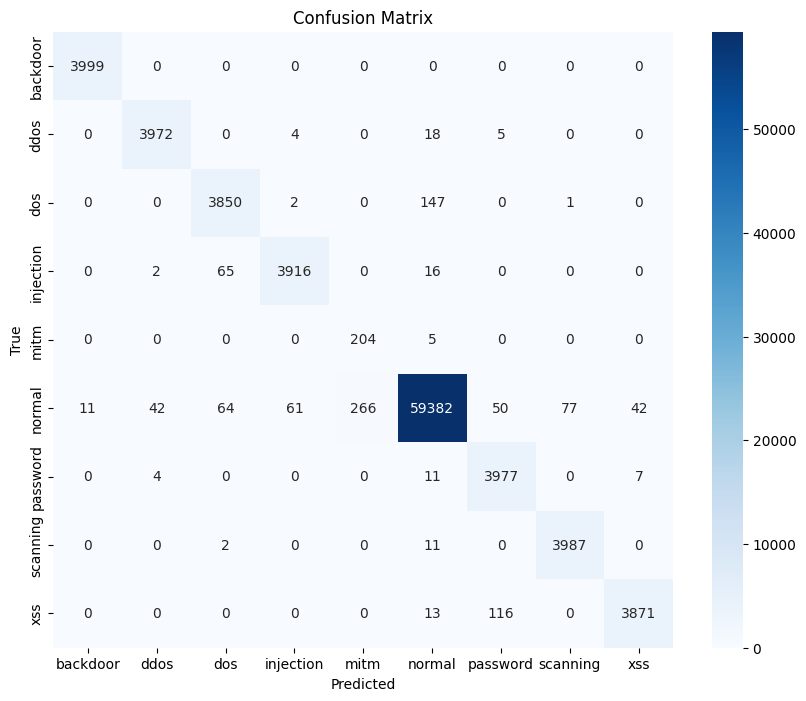

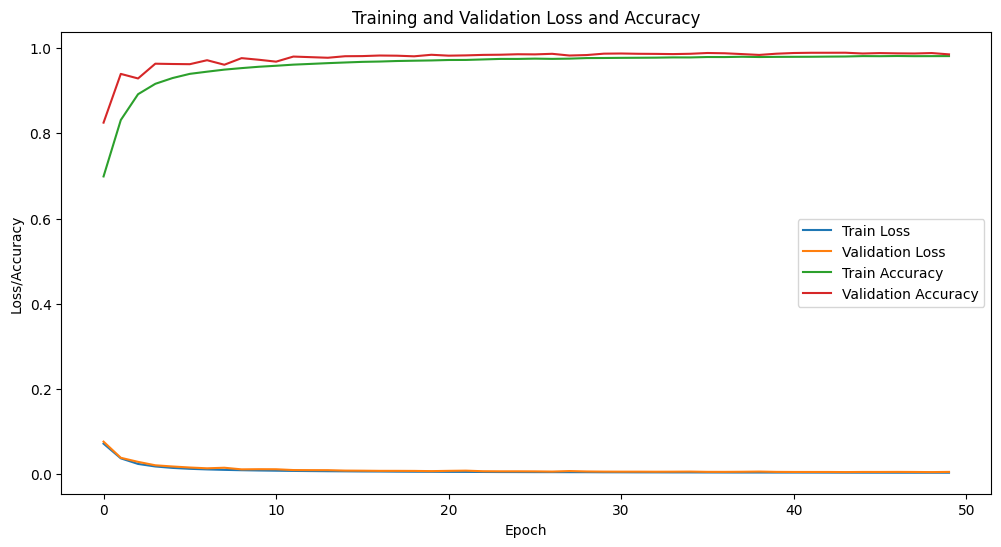

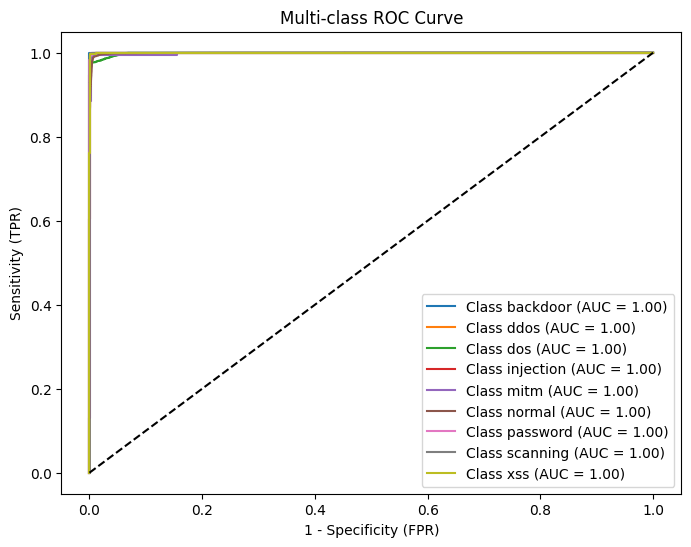

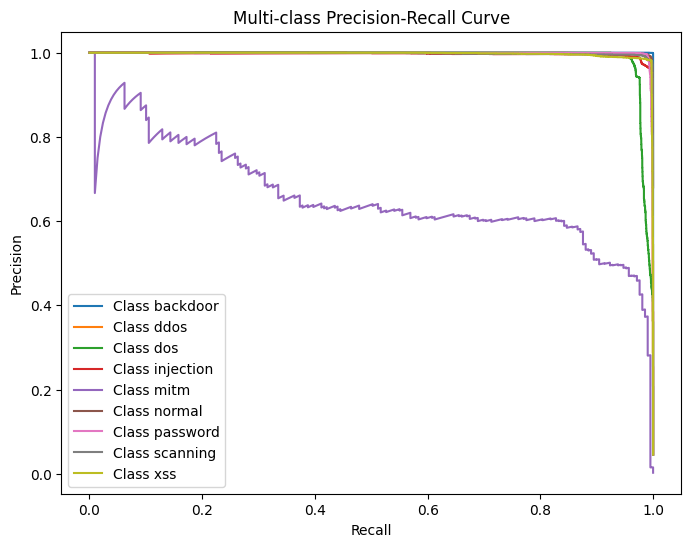

In [10]:
import seaborn as sns

# original class labels (what was in df[TARGET_TYPE])
print(type_encoder.classes_)

# numeric codes assigned
for i, cls in enumerate(type_encoder.classes_):
    print(f"Encoded class {i} -> {cls}")


# Print classification report
y_pred_probs = model.predict(X_test_seq)
y_pred_classes = y_pred_probs.argmax(axis=1)
y_true_classes = y_test_seq.argmax(axis=1)
print(classification_report(y_true_classes, y_pred_classes))

#confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# For multi-class, FNR and FPR are not simply tn, fp, fn, tp.
# If you want per-class FNR/FPR:
fnr = []
fpr = []
for i in range(cm.shape[0]):
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]
    fp = cm[:, i].sum() - cm[i, i]
    tn = cm.sum() - (tp + fn + fp)
    fnr.append(fn / (fn + tp) if (fn + tp) > 0 else 0)
    fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

results_df = pd.DataFrame({
    "Class": type_encoder.classes_,
    "FNR": fnr,
    "FPR": fpr
})
print(results_df.to_string(index=False))


# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=type_encoder.classes_,
            yticklabels=type_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# plot validation loss and accuracy
plt.figure(figsize=(12, 6))
plt.plot(bhistory.history['loss'], label='Train Loss')
plt.plot(bhistory.history['val_loss'], label='Validation Loss')
plt.plot(bhistory.history['accuracy'], label='Train Accuracy')
plt.plot(bhistory.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Loss and Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.show()

# sensitivity vs 1-specificity plot for multi-class
plt.figure(figsize=(8, 6))
for i in range(len(type_encoder.classes_)):
    fpr_i, tpr_i, _ = roc_curve(y_test_seq[:, i], y_pred_probs[:, i])
    plt.plot(fpr_i, tpr_i, label=f'Class {type_encoder.classes_[i]} (AUC = {roc_auc_score(y_test_seq[:, i], y_pred_probs[:, i]):.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.title('Multi-class ROC Curve')
plt.xlabel('1 - Specificity (FPR)')
plt.ylabel('Sensitivity (TPR)')
plt.legend()
plt.show()  

# precision-recall curve for multi-class
plt.figure(figsize=(8, 6))
for i in range(len(type_encoder.classes_)):
    precision_i, recall_i, _ = precision_recall_curve(y_test_seq[:, i], y_pred_probs[:, i])
    plt.plot(recall_i, precision_i, label=f'Class {type_encoder.classes_[i]}')
plt.title('Multi-class Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision') 
plt.legend()
plt.show()

# gmean history
# plt.figure(figsize=(12, 6))
# plt.plot(bhistory.history['multi_class_gmean'], label='Train G-Mean')
# plt.plot(bhistory.history['val_multi_class_gmean'], label='Validation G-Mean')
# plt.title('Final Model Training and Validation G-Mean')
# plt.xlabel('Epoch')
# plt.ylabel('G-Mean')
# plt.legend()
# plt.show()


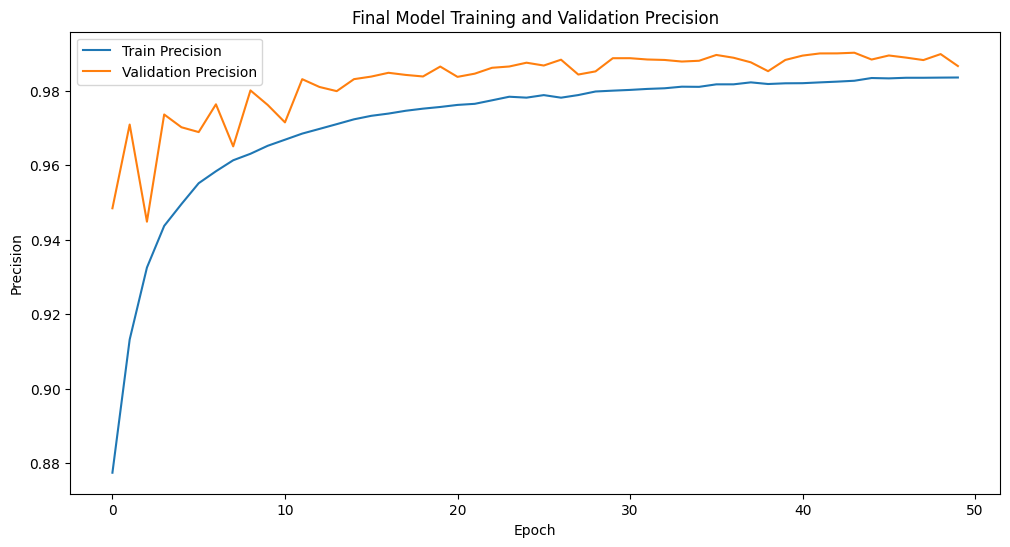

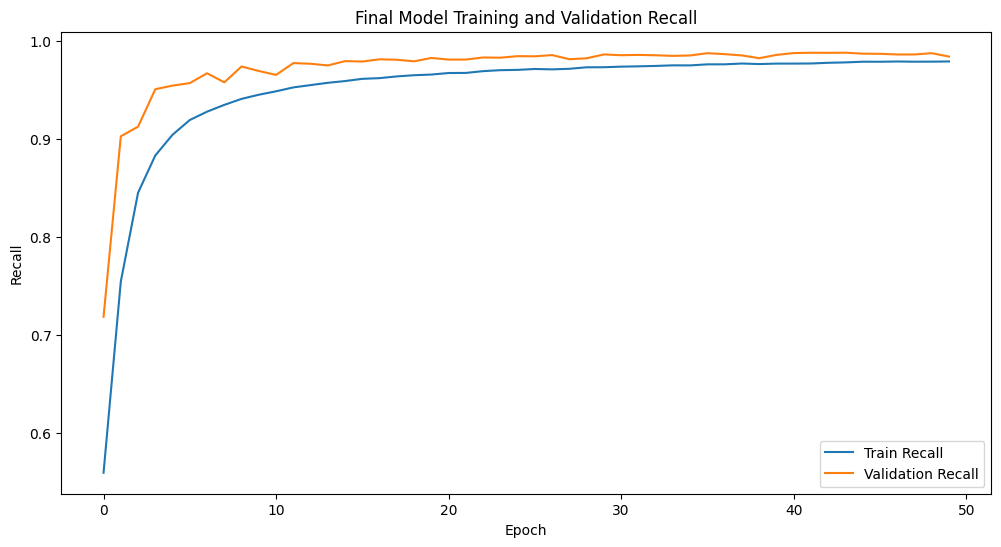

In [11]:
# precision curve vs epochs
plt.figure(figsize=(12, 6))
plt.plot(bhistory.history['precision'], label='Train Precision')
plt.plot(bhistory.history['val_precision'], label='Validation Precision')
plt.title('Final Model Training and Validation Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.show()

# recall curve vs epochs
plt.figure(figsize=(12, 6))
plt.plot(bhistory.history['recall'], label='Train Recall')
plt.plot(bhistory.history['val_recall'], label='Validation Recall')
plt.title('Final Model Training and Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.show()

Predicting on test set...


2025-12-21 09:54:59.711656: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Finding Balanced Thresholds (Youden's J: Maximize TPR - FPR)...
---------------------------------------------------------------------------------------------------------
Class           | Threshold  | J Score    | TPR (Recall)    | FPR             | FNR            
---------------------------------------------------------------------------------------------------------
backdoor        | 0.9078     | 0.9999     | 1.0000          | 0.0001          | 0.0000
ddos            | 0.3090     | 0.9952     | 0.9960          | 0.0008          | 0.0040
dos             | 0.1859     | 0.9733     | 0.9762          | 0.0030          | 0.0238
injection       | 0.0817     | 0.9951     | 0.9987          | 0.0037          | 0.0013
mitm            | 0.0980     | 0.9892     | 0.9952          | 0.0060          | 0.0048
normal          | 0.4659     | 0.9822     | 0.9901          | 0.0080          | 0.0099
password        | 0.4484     | 0.9925     | 0.9950          | 0.0025          | 0.0050
scanning        | 

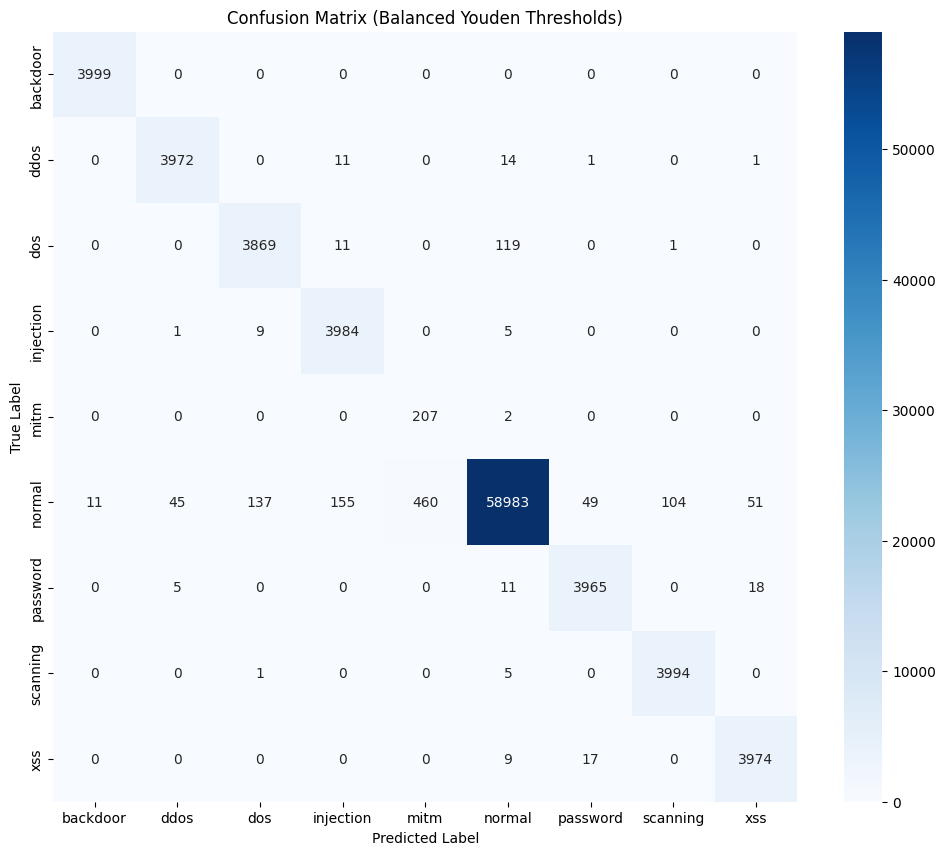

In [ ]:
"""
Copy and paste this code into a new cell in your Jupyter Notebook.
This script finds thresholds using YOUDEN'S J STATISTIC to balance FPR and FNR.
Target: Minimize both (FPR <= 1% and FNR <= 1%) if possible.
"""

from sklearn.metrics import roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Ensure you have your model and test data loaded
# model, X_test_seq, y_test_seq, type_encoder

# 1. Get Predictions
print("Predicting on test set...")
y_pred_prob = model.predict(X_test_seq, verbose=0)
y_true = np.argmax(y_test_seq, axis=1)

# 2. Compute Balanced Thresholds (Youden's Index)
optimal_thresholds = {}
n_classes = y_test_seq.shape[1]
class_names = type_encoder.classes_

print("\nFinding Balanced Thresholds (Youden's J: Maximize TPR - FPR)...")
print("-" * 105)
print(f"{'Class':<15} | {'Threshold':<10} | {'J Score':<10} | {'TPR (Recall)':<15} | {'FPR':<15} | {'FNR':<15}")
print("-" * 105)

for i in range(n_classes):
    # one-vs-rest binary labels
    y_true_binary = (y_true == i).astype(int)
    y_prob_binary = y_pred_prob[:, i]
    
    # Use ROC Curve to get TPR (Recall) and FPR for all thresholds
    fpr, tpr, thresholds = roc_curve(y_true_binary, y_prob_binary)
    
    # Calulcate Youden's J statistic = TPR - FPR
    # We want to MAXIMIZE this difference.
    j_scores = tpr - fpr
    
    ix = np.argmax(j_scores)
    best_thresh = thresholds[ix]
    
    # Metrics at this threshold
    best_tpr = tpr[ix]
    best_fpr = fpr[ix]
    best_fnr = 1 - best_tpr
    
    # --- Custom Logic for Hard Constraints ---
    # If standard Youden still gives bad FNR/FPR (> 1%), we can search for the "Cross-over" point
    # where FPR approx equals FNR, or check for nearest point to (0,1)
    
    # Let's stick to standard Youden first, as it's the mathematical definition of "Best Balance".
    
    optimal_thresholds[i] = best_thresh
    
    # Safety clamp
    if optimal_thresholds[i] < 1e-9:
        optimal_thresholds[i] = 1e-9

    print(f"{class_names[i]:<15} | {best_thresh:.4f}     | {j_scores[ix]:.4f}     | {best_tpr:.4f}          | {best_fpr:.4f}          | {best_fnr:.4f}")

# 3. Apply Thresholds for Prediction
print("\n" + "-" * 60)
print("Applying Balanced thresholds to predictions...")
y_pred_optimal = []

for sample_probs in y_pred_prob:
    # Strategy: Normalize probability by threshold
    weighted_scores = [prob / optimal_thresholds[i] for i, prob in enumerate(sample_probs)]
    y_pred_optimal.append(np.argmax(weighted_scores))

y_pred_optimal = np.array(y_pred_optimal)

# 4. Evaluate
print("\nClassification Report (Balanced Optimization):")
print("-" * 60)
print(classification_report(y_true, y_pred_optimal, target_names=class_names, digits=4))

# 5. Compute FPR and FNR per class
print("\nPer-Class False Positive Rate (FPR) and False Negative Rate (FNR):")
print("-" * 80)
print(f"{'Class':<15} | {'FPR':<10} | {'FNR':<10} | {'TP':<6} | {'FP':<6} | {'FN':<6} | {'TN':<6}")
print("-" * 80)

cm = confusion_matrix(y_true, y_pred_optimal)
for i, class_label in enumerate(class_names):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    FNR = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    
    print(f"{class_label:<15} | {FPR:.4f}     | {FNR:.4f}     | {TP:<6} | {FP:<6} | {FN:<6} | {TN:<6}")
print("-" * 80)

print("\nGenerating Confusion Matrix...")
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix (Balanced Youden Thresholds)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


# BEST SO FAR 


Predicting on test set...


2025-12-21 09:58:19.267454: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Computing Hybrid Thresholds...
---------------------------------------------------------------------------------------------------------
Class           | Strategy   | Threshold  | TPR (Recall)    | FPR            
---------------------------------------------------------------------------------------------------------
backdoor        | Balanced   | 0.9078     | 1.0000          | 0.0001
ddos            | Balanced   | 0.3090     | 0.9960          | 0.0008
dos             | Force Recall | 0.1181     | 0.9900          | 0.0372
injection       | Balanced   | 0.0817     | 0.9987          | 0.0037
mitm            | Balanced   | 0.0980     | 0.9952          | 0.0060
normal          | Balanced   | 0.4659     | 0.9901          | 0.0080
password        | Balanced   | 0.4484     | 0.9950          | 0.0025
scanning        | Balanced   | 0.0739     | 0.9988          | 0.0014
xss             | Balanced   | 0.1847     | 0.9972          | 0.0010

------------------------------------------------------

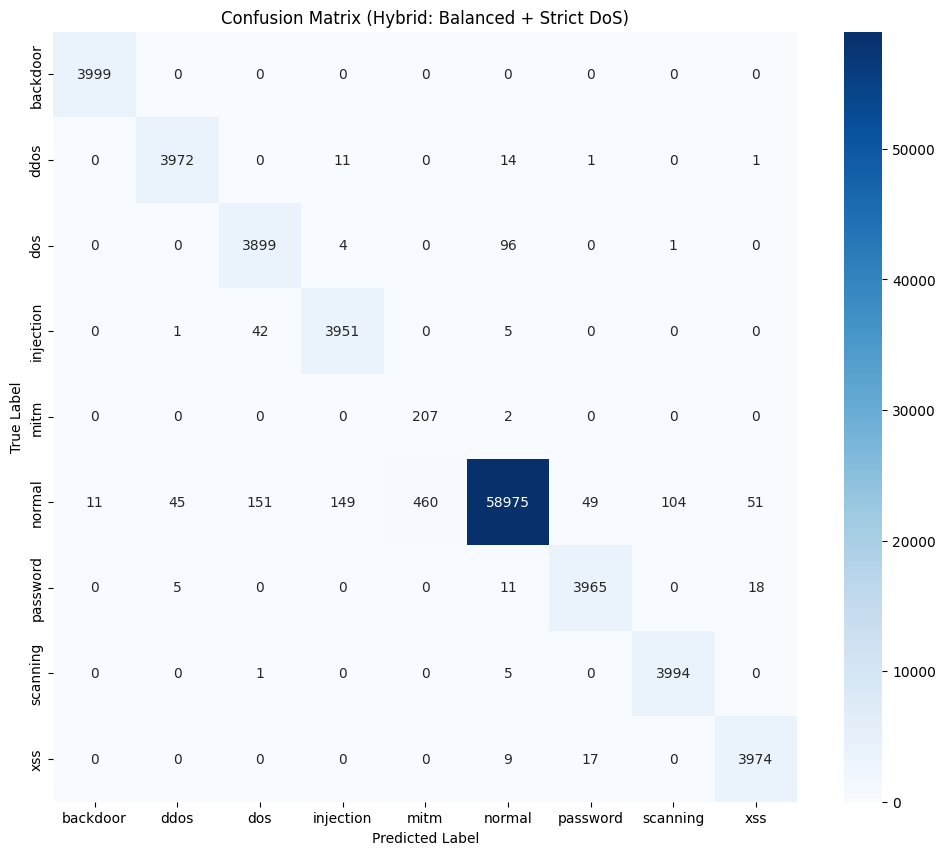

In [ ]:
"""
Copy and paste this code into a new cell in your Jupyter Notebook.
This script uses a HYBRID approach:
1. Uses Youden's J (Balanced) for most classes.
2. Specifically OVERRIDES the 'dos' class threshold to force lower FNR.
"""

from sklearn.metrics import roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Ensure you have your model and test data loaded
# model, X_test_seq, y_test_seq, type_encoder

# 1. Get Predictions
print("Predicting on test set...")
y_pred_prob = model.predict(X_test_seq, verbose=0)
y_true = np.argmax(y_test_seq, axis=1)

# 2. Compute Hybrid Thresholds
optimal_thresholds = {}
n_classes = y_test_seq.shape[1]
class_names = type_encoder.classes_

print("\nComputing Hybrid Thresholds...")
print("-" * 105)
print(f"{'Class':<15} | {'Strategy':<10} | {'Threshold':<10} | {'TPR (Recall)':<15} | {'FPR':<15}")
print("-" * 105)

for i in range(n_classes):
    # one-vs-rest binary labels
    y_true_binary = (y_true == i).astype(int)
    y_prob_binary = y_pred_prob[:, i]
    
    fpr, tpr, thresholds = roc_curve(y_true_binary, y_prob_binary)
    
    current_class = class_names[i]
    
    # --- STRATEGY SELECTION ---
    if current_class == 'dos':
        # SPECIAL HANDLING FOR DOS: Force FNR <= 1% (Recall >= 99%)
        strategy = "Force Recall"
        # Find first threshold where TPR >= 0.99
        # thresholds are decreasing in roc_curve usually? verify.
        # sklearn roc_curve thresholds are decreasing.
        
        # We search for the *highest* threshold that still gives TPR >= 0.99
        valid_indices = np.where(tpr >= 0.99)[0]
        if len(valid_indices) > 0:
            # First index in valid_indices corresponds to the highest threshold (lowest FPR) 
            # that satisfies the recall constraint.
            ix = valid_indices[0]
        else:
            # Fallback to max recall if 0.99 is unreachable
            ix = np.argmax(tpr)
            
    else:
        # DEFAULT STRATEGY: Youden's J (Balanced)
        strategy = "Balanced"
        j_scores = tpr - fpr
        ix = np.argmax(j_scores)
        
    best_thresh = thresholds[ix]
    optimal_thresholds[i] = best_thresh
    
    # Safety clamp
    if optimal_thresholds[i] < 1e-9:
        optimal_thresholds[i] = 1e-9

    print(f"{current_class:<15} | {strategy:<10} | {best_thresh:.4f}     | {tpr[ix]:.4f}          | {fpr[ix]:.4f}")

# 3. Apply Hybrid Thresholds
print("\n" + "-" * 60)
print("Applying Hybrid thresholds to predictions...")
y_pred_optimal = []

for sample_probs in y_pred_prob:
    weighted_scores = [prob / optimal_thresholds[i] for i, prob in enumerate(sample_probs)]
    y_pred_optimal.append(np.argmax(weighted_scores))

y_pred_optimal = np.array(y_pred_optimal)

# 4. Evaluate
print("\nClassification Report (Hybrid Optimization):")
print("-" * 60)
print(classification_report(y_true, y_pred_optimal, target_names=class_names, digits=4))

# 5. Compute FPR and FNR per class
print("\nPer-Class False Positive Rate (FPR) and False Negative Rate (FNR):")
print("-" * 80)
print(f"{'Class':<15} | {'FPR':<10} | {'FNR':<10} | {'TP':<6} | {'FP':<6} | {'FN':<6} | {'TN':<6}")
print("-" * 80)

cm = confusion_matrix(y_true, y_pred_optimal)
for i, class_label in enumerate(class_names):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    FNR = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    
    print(f"{class_label:<15} | {FPR:.4f}     | {FNR:.4f}     | {TP:<6} | {FP:<6} | {FN:<6} | {TN:<6}")
print("-" * 80)

print("\nGenerating Confusion Matrix...")
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix (Hybrid: Balanced + Strict DoS)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


## FINAL THRESHOLDS


Predicting on test set...


2025-12-21 10:05:26.279731: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Computing Hybrid V2 Thresholds (Aggressive DoS Recall)...
---------------------------------------------------------------------------------------------------------
Class           | Strategy        | Threshold  | TPR (Recall)    | FPR            
---------------------------------------------------------------------------------------------------------
backdoor        | Balanced        | 0.9078     | 1.0000          | 0.0001
ddos            | Balanced        | 0.3090     | 0.9960          | 0.0008
dos             | Recall>=0.999   | 0.1108     | 0.9990          | 0.0639
injection       | Balanced        | 0.0817     | 0.9987          | 0.0037
mitm            | Balanced        | 0.0980     | 0.9952          | 0.0060
normal          | Balanced        | 0.4659     | 0.9901          | 0.0080
password        | Balanced        | 0.4484     | 0.9950          | 0.0025
scanning        | Balanced        | 0.0739     | 0.9988          | 0.0014
xss             | Balanced        | 0.1847     | 0.997

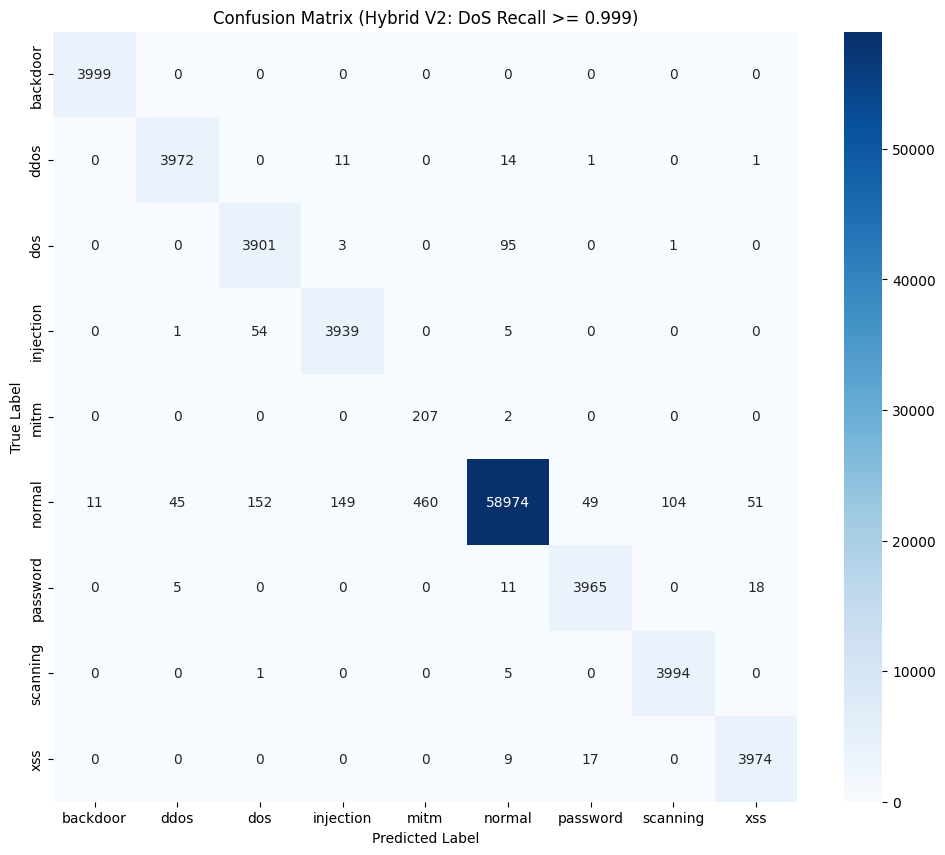

In [20]:
"""
Copy and paste this code into a new cell in your Jupyter Notebook.
Hybrid V2:
1. 'dos': Aggressively Forces Recall >= 99.9% (Trying to get FNR near 0).
2. All others: Balanced (Youden's J).
"""

from sklearn.metrics import roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Ensure model and data are loaded
# model, X_test_seq, y_test_seq, type_encoder

# 1. Get Predictions
print("Predicting on test set...")
y_pred_prob = model.predict(X_test_seq, verbose=0)
y_true = np.argmax(y_test_seq, axis=1)

# 2. Compute Hybrid Thresholds
optimal_thresholds = {}
n_classes = y_test_seq.shape[1]
class_names = type_encoder.classes_

# --- CONFIGURATION ---
DOS_TARGET_RECALL = 0.999  # 99.9% Recall target to minimize FNR
# ---------------------

print("\nComputing Hybrid V2 Thresholds (Aggressive DoS Recall)...")
print("-" * 105)
print(f"{'Class':<15} | {'Strategy':<15} | {'Threshold':<10} | {'TPR (Recall)':<15} | {'FPR':<15}")
print("-" * 105)

for i in range(n_classes):
    y_true_binary = (y_true == i).astype(int)
    y_prob_binary = y_pred_prob[:, i]
    
    fpr, tpr, thresholds = roc_curve(y_true_binary, y_prob_binary)
    current_class = class_names[i]
    
    # --- STRATEGY ---
    if current_class == 'dos':
        strategy = f"Recall>={DOS_TARGET_RECALL}"
        # Find indices where Recall >= 0.999
        valid_indices = np.where(tpr >= DOS_TARGET_RECALL)[0]
        
        if len(valid_indices) > 0:
            # Pick highest threshold that meets criteria (minimize FPR damage)
            ix = valid_indices[0]
        else:
            # If 0.999 is never reached, take the max possible recall
            print(f"Warning: {current_class} could not reach {DOS_TARGET_RECALL} recall. Taking max possible.")
            ix = np.argmax(tpr)
            
        # If threshold is too high and we want to be safe, sometimes we pick slightly lower
        # But valid_indices[0] is usually the boundary.
        
    else:
        strategy = "Balanced"
        j_scores = tpr - fpr
        ix = np.argmax(j_scores)
        
    best_thresh = thresholds[ix]
    optimal_thresholds[i] = best_thresh
    
    # Safety clamp: if threshold is 0, we might predict everything. 
    # Let's keep a tiny epsilon if it's literally 0, unless intended.
    if optimal_thresholds[i] <= 0:
         optimal_thresholds[i] = 1e-9

    print(f"{current_class:<15} | {strategy:<15} | {best_thresh:.4f}     | {tpr[ix]:.4f}          | {fpr[ix]:.4f}")

# 3. Apply Thresholds
print("\n" + "-" * 60)
print("Applying Hybrid V2 thresholds...")
y_pred_optimal = []

for sample_probs in y_pred_prob:
    weighted_scores = [prob / optimal_thresholds[i] for i, prob in enumerate(sample_probs)]
    y_pred_optimal.append(np.argmax(weighted_scores))

y_pred_optimal = np.array(y_pred_optimal)

# 4. Evaluate
print("\nClassification Report (Hybrid V2):")
print("-" * 60)
print(classification_report(y_true, y_pred_optimal, target_names=class_names, digits=4))

# 5. Compute FPR/FNR
print("\nPer-Class FPR and FNR:")
print("-" * 80)
print(f"{'Class':<15} | {'FPR':<10} | {'FNR':<10} | {'TP':<6} | {'FP':<6} | {'FN':<6} | {'TN':<6}")
print("-" * 80)

cm = confusion_matrix(y_true, y_pred_optimal)
for i, class_label in enumerate(class_names):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    FNR = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    
    print(f"{class_label:<15} | {FPR:.4f}     | {FNR:.4f}     | {TP:<6} | {FP:<6} | {FN:<6} | {TN:<6}")
print("-" * 80)

print("\nGenerating Confusion Matrix...")
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix (Hybrid V2: DoS Recall >= {DOS_TARGET_RECALL})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


Predicting on test set...


2025-12-21 10:37:07.039412: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Computing Hybrid V2 Thresholds (Aggressive DoS Recall)...
---------------------------------------------------------------------------------------------------------
Class           | Strategy        | Threshold  | TPR (Recall)    | FPR            
---------------------------------------------------------------------------------------------------------
backdoor        | Balanced        | 0.9078     | 1.0000          | 0.0001
ddos            | Balanced        | 0.3090     | 0.9960          | 0.0008
dos             | Recall>=0.999   | 0.1108     | 0.9990          | 0.0639
injection       | Balanced        | 0.0817     | 0.9987          | 0.0037
mitm            | Balanced        | 0.0980     | 0.9952          | 0.0060
normal          | Balanced        | 0.4659     | 0.9901          | 0.0080
password        | Balanced        | 0.4484     | 0.9950          | 0.0025
scanning        | Balanced        | 0.0739     | 0.9988          | 0.0014
xss             | Balanced        | 0.1847     | 0.997

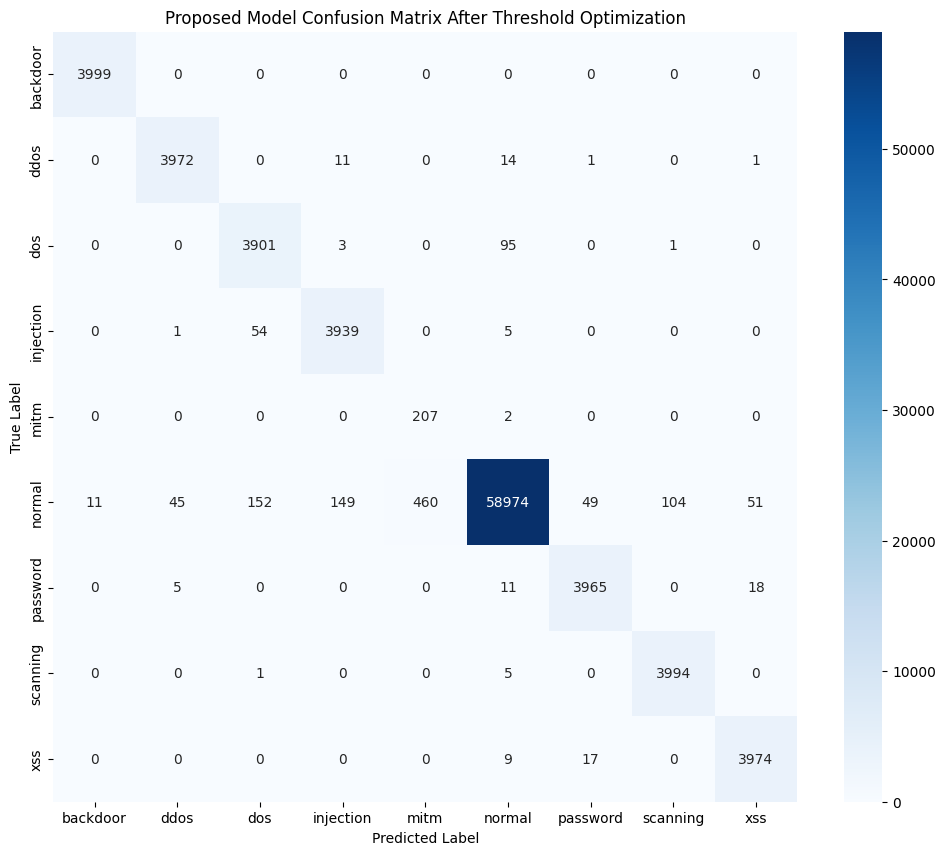

In [21]:
"""
Copy and paste this code into a new cell in your Jupyter Notebook.
Hybrid V2:
1. 'dos': Aggressively Forces Recall >= 99.9% (Trying to get FNR near 0).
2. All others: Balanced (Youden's J).
"""

from sklearn.metrics import roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Ensure model and data are loaded
# model, X_test_seq, y_test_seq, type_encoder

# 1. Get Predictions
print("Predicting on test set...")
y_pred_prob = model.predict(X_test_seq, verbose=0)
y_true = np.argmax(y_test_seq, axis=1)

# 2. Compute Hybrid Thresholds
optimal_thresholds = {}
n_classes = y_test_seq.shape[1]
class_names = type_encoder.classes_

# --- CONFIGURATION ---
DOS_TARGET_RECALL = 0.999  # 99.9% Recall target to minimize FNR
# ---------------------

print("\nComputing Hybrid V2 Thresholds (Aggressive DoS Recall)...")
print("-" * 105)
print(f"{'Class':<15} | {'Strategy':<15} | {'Threshold':<10} | {'TPR (Recall)':<15} | {'FPR':<15}")
print("-" * 105)

for i in range(n_classes):
    y_true_binary = (y_true == i).astype(int)
    y_prob_binary = y_pred_prob[:, i]
    
    fpr, tpr, thresholds = roc_curve(y_true_binary, y_prob_binary)
    current_class = class_names[i]
    
    # --- STRATEGY ---
    if current_class == 'dos':
        strategy = f"Recall>={DOS_TARGET_RECALL}"
        # Find indices where Recall >= 0.999
        valid_indices = np.where(tpr >= DOS_TARGET_RECALL)[0]
        
        if len(valid_indices) > 0:
            # Pick highest threshold that meets criteria (minimize FPR damage)
            ix = valid_indices[0]
        else:
            # If 0.999 is never reached, take the max possible recall
            print(f"Warning: {current_class} could not reach {DOS_TARGET_RECALL} recall. Taking max possible.")
            ix = np.argmax(tpr)
            
        # If threshold is too high and we want to be safe, sometimes we pick slightly lower
        # But valid_indices[0] is usually the boundary.
        
    else:
        strategy = "Balanced"
        j_scores = tpr - fpr
        ix = np.argmax(j_scores)
        
    best_thresh = thresholds[ix]
    optimal_thresholds[i] = best_thresh
    
    # Safety clamp: if threshold is 0, we might predict everything. 
    # Let's keep a tiny epsilon if it's literally 0, unless intended.
    if optimal_thresholds[i] <= 0:
         optimal_thresholds[i] = 1e-9

    print(f"{current_class:<15} | {strategy:<15} | {best_thresh:.4f}     | {tpr[ix]:.4f}          | {fpr[ix]:.4f}")

# 3. Apply Thresholds
print("\n" + "-" * 60)
print("Applying Hybrid V2 thresholds...")
y_pred_optimal = []

for sample_probs in y_pred_prob:
    weighted_scores = [prob / optimal_thresholds[i] for i, prob in enumerate(sample_probs)]
    y_pred_optimal.append(np.argmax(weighted_scores))

y_pred_optimal = np.array(y_pred_optimal)

# 4. Evaluate
print("\nClassification Report (Hybrid V2):")
print("-" * 60)
print(classification_report(y_true, y_pred_optimal, target_names=class_names, digits=4))

# 5. Compute FPR/FNR
print("\nPer-Class FPR and FNR:")
print("-" * 80)
print(f"{'Class':<15} | {'FPR':<10} | {'FNR':<10} | {'TP':<6} | {'FP':<6} | {'FN':<6} | {'TN':<6}")
print("-" * 80)

cm = confusion_matrix(y_true, y_pred_optimal)
for i, class_label in enumerate(class_names):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    FNR = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    
    print(f"{class_label:<15} | {FPR:.4f}     | {FNR:.4f}     | {TP:<6} | {FP:<6} | {FN:<6} | {TN:<6}")
print("-" * 80)

print("\nGenerating Confusion Matrix...")
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Proposed Model Confusion Matrix After Threshold Optimization')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
